In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import shap

df = pd.read_csv('incident records.csv')

In [2]:
# Converting to 1/0

df['nkill'] = df['nkill'].astype(int)
df['nwound'] = df['nwound'].astype(int)

In [14]:
df["deadly_incident"] = (df["nkill"] > 0).astype(int)

In [16]:
# Random Forest
features = ['iyear', 'region_txt', 'country_txt', 'nwound']
X = df[features]
y = df['deadly_incident']

X_encoded = pd.get_dummies(X, drop_first=False)

X = pd.get_dummies( X, columns=["region_txt", "country_txt"], drop_first=True, dtype=int )

X_train, X_test, y_train, y_test, = train_test_split( 
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Random forest test accuracy:", rf.score(X_test, y_test))

Random forest test accuracy: 0.695


In [18]:
# SHAP Setup
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)


# Getting countries/inde
country_cols = [col for col in X_test.columns if col.startswith("country_txt_")]
country_idx = [X_test.columns.get_loc(col) for col in country_cols]

# SHAP Values by country
country_shap = shap_values.values[:, country_idx, 1]

country_shap_mean = pd.Series(
    country_shap.mean(axis=0),
    index=country_cols
).sort_values(ascending=False)

country_shap_importance = pd.Series(
    abs(country_shap).mean(axis=0),
    index=country_cols
).sort_values(ascending=False)


# Country formatting
country_shap_importance.index = (
    country_shap_importance.index
    .str.replace("country_txt_", "", regex=False)
    .str.replace("_", " ", regex=False)
)

print(country_shap_mean)
print(country_shap_importance)

country_txt_Chile            0.003286
country_txt_United States    0.003115
country_txt_Canada           0.001623
country_txt_Bolivia          0.000978
country_txt_Mexico           0.000330
country_txt_Ecuador          0.000239
country_txt_Uruguay         -0.000149
country_txt_Guyana          -0.000409
country_txt_Venezuela       -0.000522
country_txt_Paraguay        -0.000685
country_txt_Peru            -0.000781
country_txt_Brazil          -0.001401
country_txt_Colombia        -0.002328
dtype: float64
Colombia         0.042909
United States    0.015346
Mexico           0.012675
Chile            0.008594
Peru             0.006471
Paraguay         0.004542
Canada           0.003883
Brazil           0.003759
Venezuela        0.002092
Ecuador          0.001450
Bolivia          0.000978
Guyana           0.000655
Uruguay          0.000172
dtype: float64


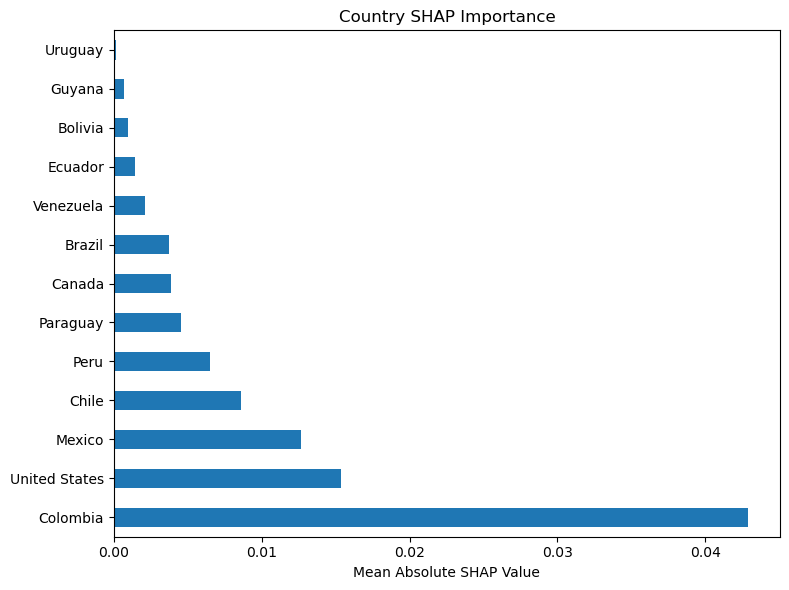

In [21]:
# Country SHAP Importance (comparing any deadly incident)

country_shap_importance.plot(kind='barh', figsize=(8, 6))
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Country SHAP Importance")
plt.tight_layout()
plt.show()

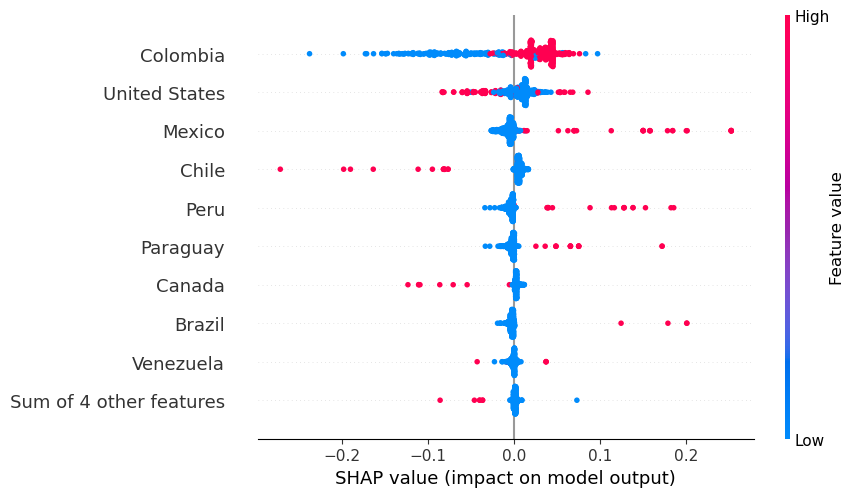

In [20]:
shap_country = shap_values[:, country_idx, 1]

shap_country.feature_names = [
    col.replace("country_txt_", "").replace("_", " ")
    for col in country_cols
]

shap.plots.beeswarm(shap_country)

In [ ]:
# Comparing wound values

features = ['nwound']
X = df[features]
y = df['nkill']

X_encoded = pd.get_dummies(X, drop_first=False)

X = pd.get_dummies( X, columns=["region_txt", "country_txt"], drop_first=True, dtype=int )

X_train, X_test, y_train, y_test, = train_test_split( 
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Random forest test accuracy:", rf.score(X_test, y_test))